In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

In [2]:
data = np.load("windows_500_50.npz", allow_pickle=True)

X = data["X"]
y_env = data["y_env"]

print("Dataset shape:", X.shape)

Dataset shape: (3297, 500)


In [3]:
encoder = LabelEncoder()

y = encoder.fit_transform(y_env)

print("Classes:", encoder.classes_)

Classes: ['bridge' 'forest' 'garden' 'lake' 'river']


In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    stratify=y,
    random_state=42
)

In [6]:
rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train, y_train)

,n_estimators,200
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [7]:
importance = rf.feature_importances_

print("Feature vector size:", importance.shape)

Feature vector size: (500,)


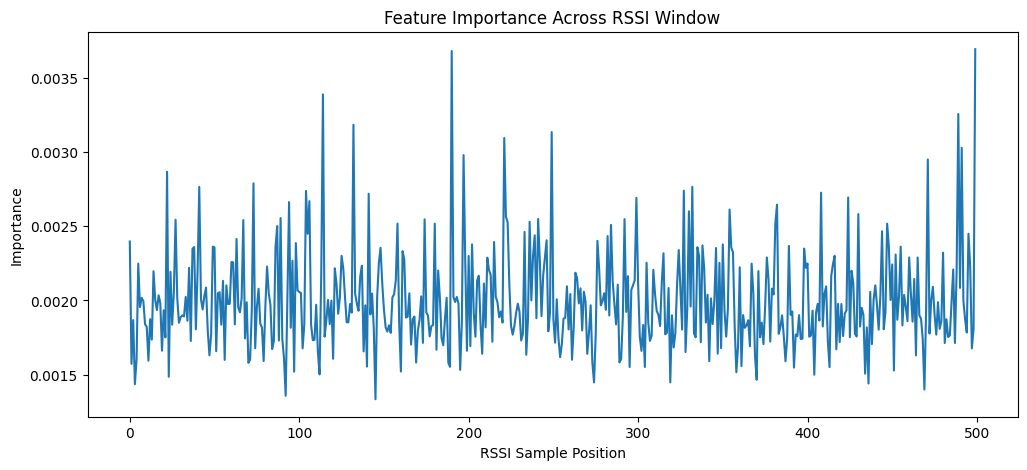

In [8]:
plt.figure(figsize=(12,5))

plt.plot(importance)

plt.title("Feature Importance Across RSSI Window")
plt.xlabel("RSSI Sample Position")
plt.ylabel("Importance")

plt.show()

In [9]:
top_idx = np.argsort(importance)[-20:]

top_idx

array([299, 424, 141, 408, 104, 327,  41, 332,  73,  22, 471, 197, 491,
       221, 249, 132, 489, 114, 190, 499])

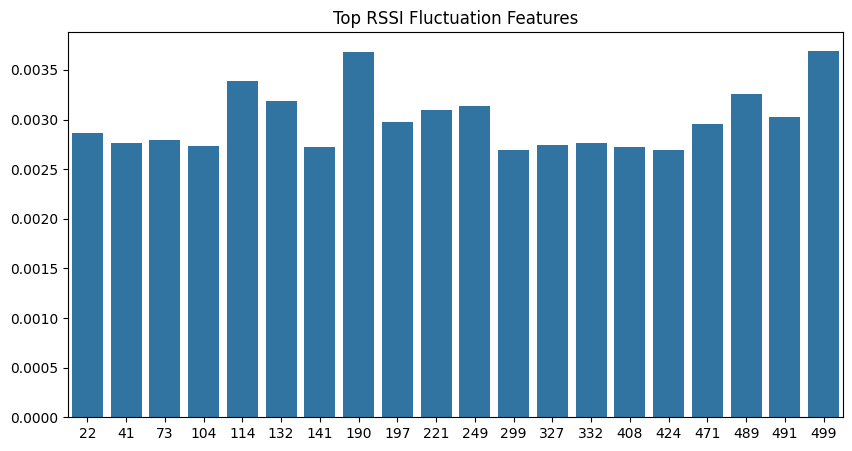

In [10]:
plt.figure(figsize=(10,5))

sns.barplot(
    x=top_idx,
    y=importance[top_idx]
)

plt.title("Top RSSI Fluctuation Features")

plt.show()

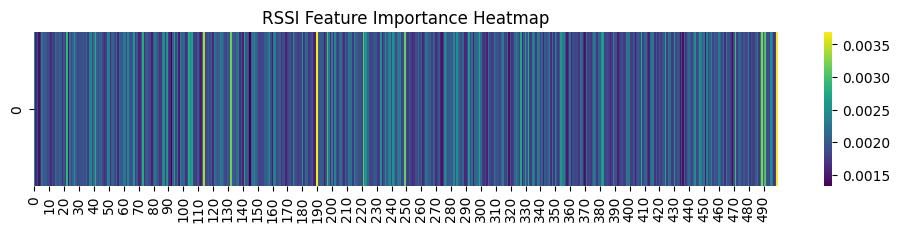

In [11]:
plt.figure(figsize=(12,2))

sns.heatmap(
    importance.reshape(1,-1),
    cmap="viridis",
    cbar=True
)

plt.title("RSSI Feature Importance Heatmap")

plt.show()

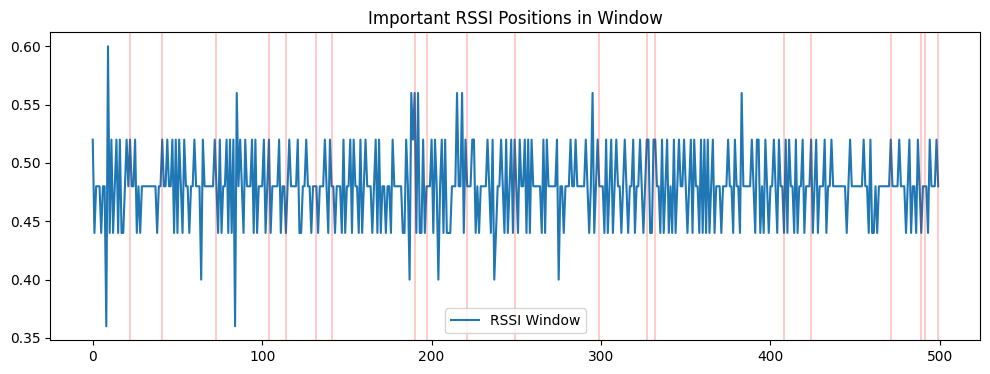

In [12]:
sample = X_train[0]

plt.figure(figsize=(12,4))

plt.plot(sample, label="RSSI Window")

for idx in top_idx:
    plt.axvline(idx, color="red", alpha=0.2)

plt.title("Important RSSI Positions in Window")

plt.legend()

plt.show()